In [9]:
"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""
import numpy as np
# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
# (5 points)
# TODO: Create the matrix described above
# Hint: Use np.ones and array slicing

arr = np.ones((5, 5))
arr[1:-1,1:-1] = 0

# Task 2: Normalize a random array
# (5 points)
np.random.seed(42)
random_data = np.random.randn(100, 3)
# TODO: Normalize each column to have mean=0 and std=1
normalized_data = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)

# Task 3: Implement linear regression solution using normal equation
# (10 points)
# Given X (features) and y (target), compute theta
# theta = (X^T X)^(-1) X^T y


X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
# TODO: Calculate theta_hat using the normal equation
X_T = X.T
theta_hat = np.linalg.pinv(X_T @ X) @ X_T @ y
# TODO: Print the estimated coefficients and compare with true_theta 
print("Estimated coefficients:", theta_hat)
print("True_theta:", true_theta)

Estimated coefficients: [ 2.51723721 -1.19783796  3.72399266]
True_theta: [ 2.5 -1.2  3.7]


In [14]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration (10 points)
print(df.info())
print(df.head())

print(df.isnull().sum())

df['exam_score'] = df['exam_score'].fillna(df.groupby('major')['exam_score'].transform('mean'))

df['hours_studied'] = df['hours_studied'].fillna(df.groupby('year')['hours_studied'].transform('median'))

# Task 2: Analysis (10 points)
print(df.groupby('major')['exam_score'].mean())

print(df.groupby('major')['hours_studied'].mean().idxmax())

print(df[['hours_studied', 'exam_score']].corr())

def categorize(score):
    if score >= 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'
df['performance'] = df['exam_score'].apply(categorize)

print(df['performance'].value_counts())

# Task 3: Advanced Analysis (10 points)
summary = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
)

print(summary)

top_students = df.sort_values('exam_score', ascending=False).head(5)
print(top_students)

pivot = pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print(pivot)

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB
None
   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1   67.856486                      2      14.042336
4        1004  Physics 

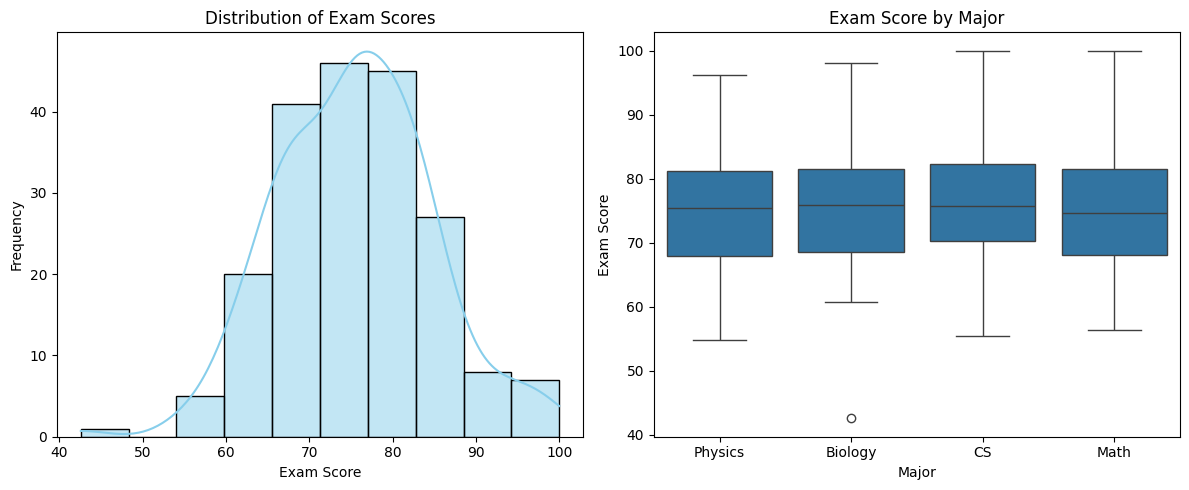

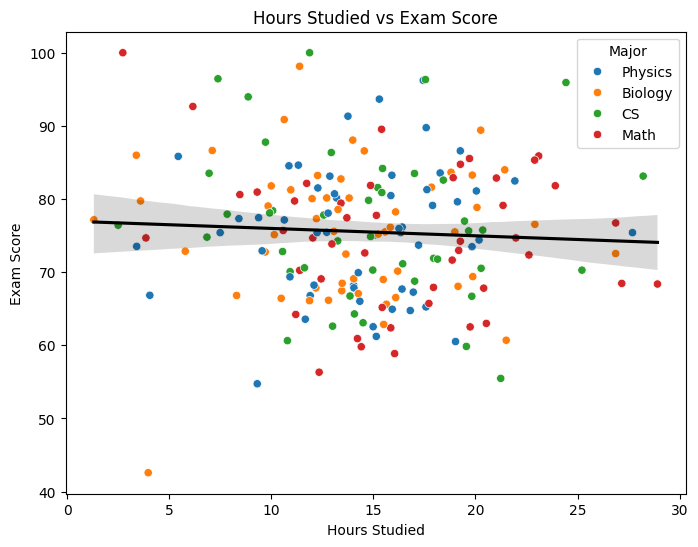

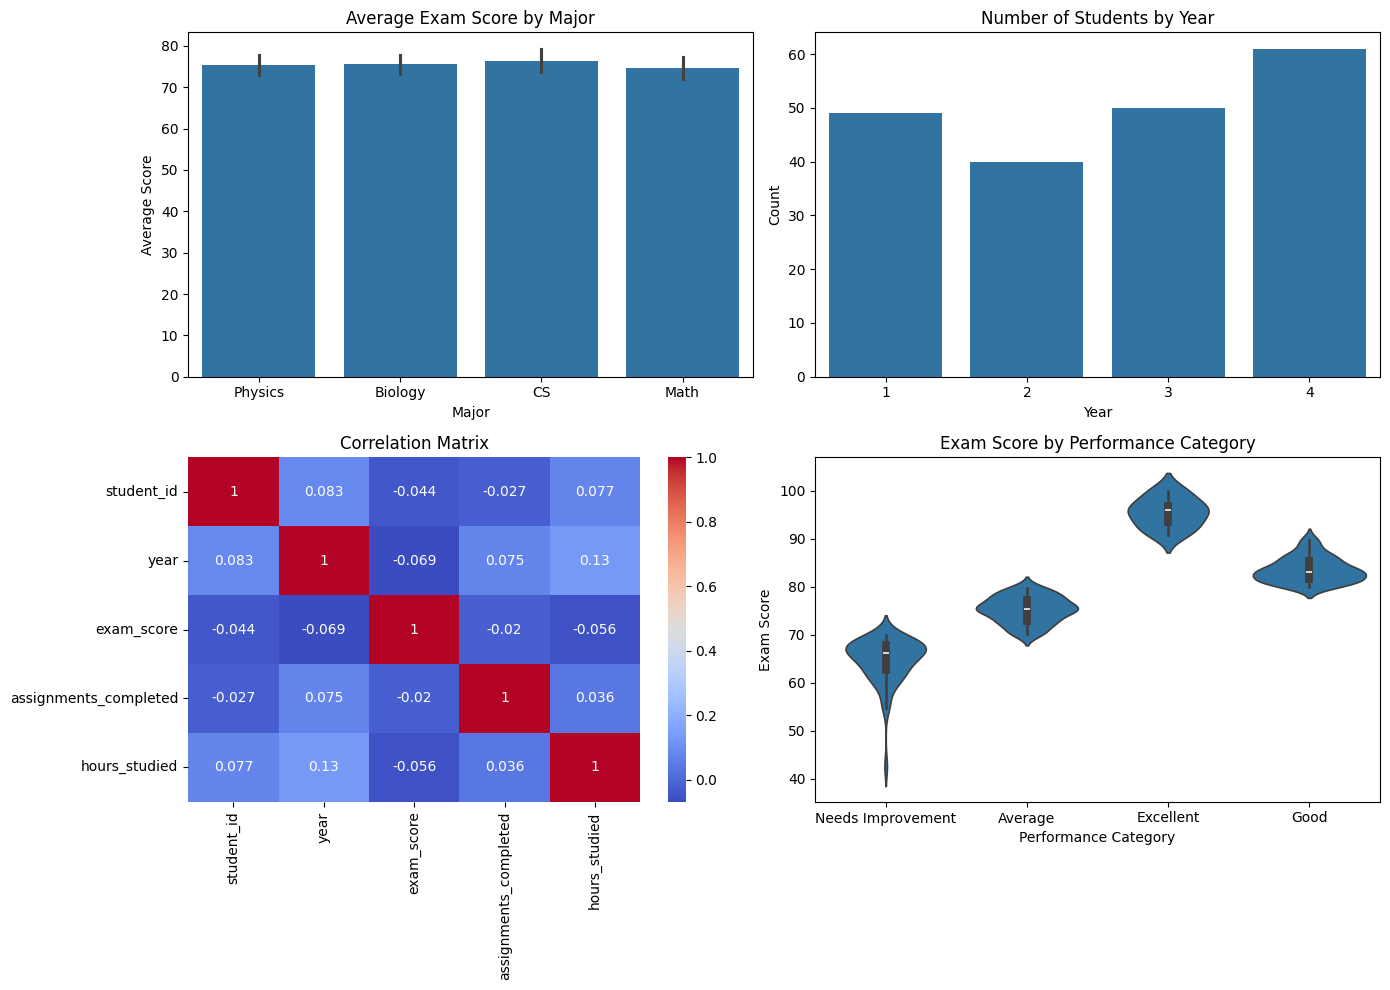

In [16]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns

# Continue using the df from Exercise 5

# Task 1: Distribution Visualization (8 points)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Left: Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['exam_score'], kde=True, bins=10, color='skyblue')
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')

# Right: Boxplot by major
plt.subplot(1, 2, 2)
sns.boxplot(x='major', y='exam_score', data=df)
plt.title('Exam Score by Major')
plt.xlabel('Major')
plt.ylabel('Exam Score')

plt.tight_layout()
plt.show()

# Task 2: Relationship Visualization (8 points)
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='hours_studied',
    y='exam_score',
    hue='major',
    data=df
)

# Regression line (overall trend)
sns.regplot(
    x='hours_studied',
    y='exam_score',
    data=df,
    scatter=False,
    color='black'
)

plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend(title='Major')
plt.show()

# Task 3: Advanced Dashboard (9 points)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart: Average exam score by major
sns.barplot(x='major', y='exam_score', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Score')

# 2. Count plot: Number of students by year
sns.countplot(x='year', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Number of Students by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')

# 3. Heatmap: Correlation matrix
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('Correlation Matrix')

# 4. Violin plot: Exam score by performance category
sns.violinplot(x='performance', y='exam_score', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Exam Score by Performance Category')
axes[1, 1].set_xlabel('Performance Category')
axes[1, 1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

           num_customers    avg_income     avg_clv      total_clv
age_group                                                        
18-25                 81  50634.018330  718.371170   58188.064760
26-35                 73  48747.148046  747.738562   54584.915035
36-50                160  48516.895668  732.796612  117247.457917
51-70                186  50713.163384  762.693498  141860.990683
    age        income  purchase_frequency  avg_purchase_value  churn_risk  \
6    38  58876.388563                  10          110.331527    0.166667   
9    40  48809.492879                  10          110.228581    0.166667   
19   41  21282.756976                   8          119.651218    0.333333   
24   38  53981.193911                   8          120.320786    0.333333   
57   64  45956.146951                   7          135.470585    0.416667   

            clv age_group  
6   1287.201143     36-50  
9   1286.000108     36-50  
19  1276.279663     36-50  
24  1283.421714     36-50  
5

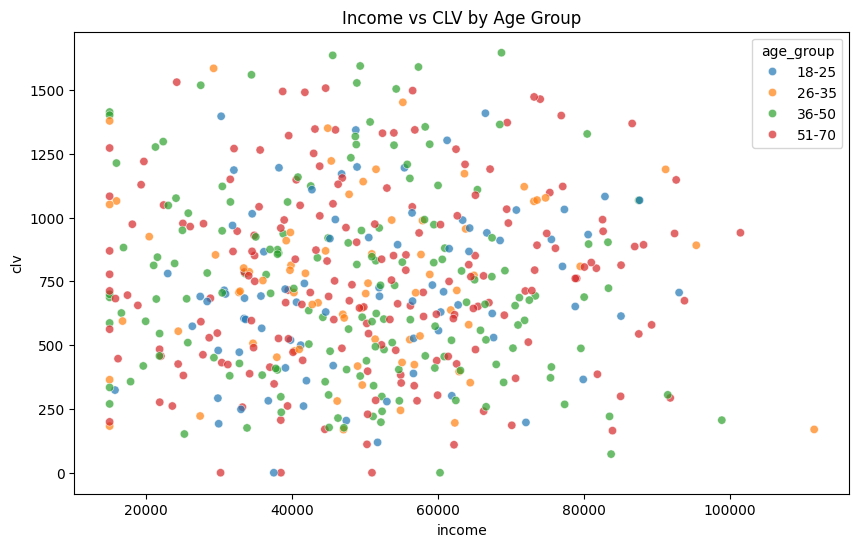

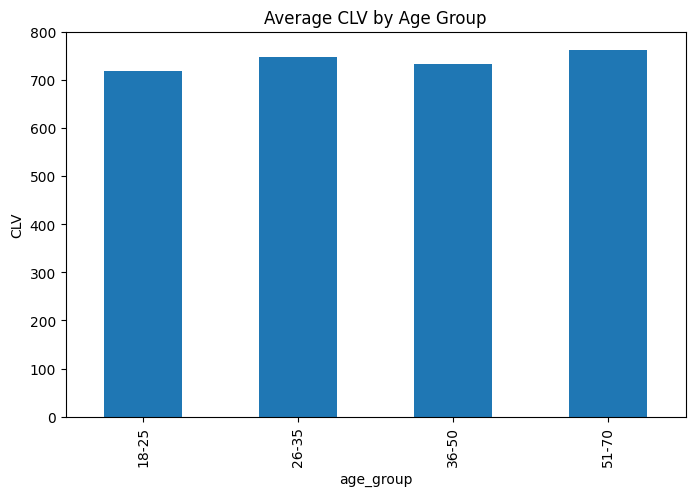

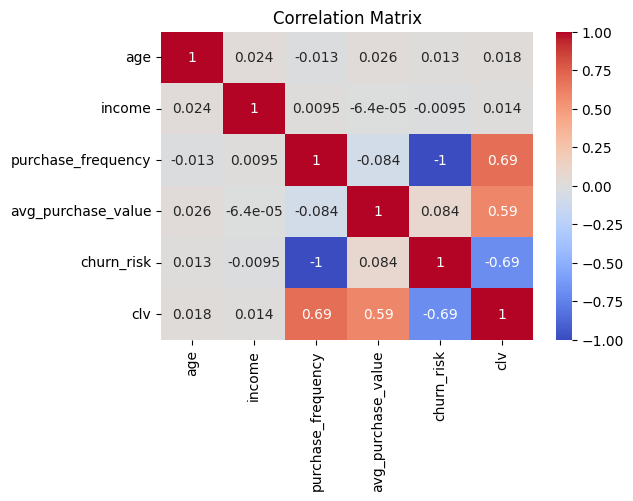

In [17]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# max frequency for churn calculation
max_frequency = customers['purchase_frequency'].max()

customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)

customers['clv'] = (
    customers['purchase_frequency']
    * customers['avg_purchase_value']
    * (1 + customers['churn_risk'])
)

bins = [18, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51-70']

customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels, include_lowest=True)

age_group_stats = customers.groupby('age_group').agg(
    num_customers=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_clv=('clv', 'mean'),
    total_clv=('clv', 'sum')
)

print(age_group_stats)

top_10_threshold = customers['clv'].quantile(0.9)
top_customers = customers[customers['clv'] >= top_10_threshold]

print(top_customers.head())

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=customers,
    x='income',
    y='clv',
    hue='age_group',
    alpha=0.7
)
plt.title('Income vs CLV by Age Group')
plt.show()

plt.figure(figsize=(8,5))
age_group_stats['avg_clv'].plot(kind='bar')
plt.title('Average CLV by Age Group')
plt.ylabel('CLV')
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(customers.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

